# Monte Carlo Methods Using Class Implementation

This notebook uses the `MonteCarloSimulation` class for pricing Asian options using various Monte Carlo methods.

In [1]:
%load_ext autoreload
%autoreload 2

import lib
import numpy as np
import matplotlib.pyplot as plt

## Initialize the Simulation

Create a simulation instance with our model parameters:

In [21]:
# Model parameters
S0, K = 100, 100     # Initial stock price and strike
r = 0.04             # Risk-free rate
sigma = 2.0          # Volatility
gamma = 0.9          # CEV parameter
T = 1.0              # Time to maturity
M = 252              # Number of time steps (daily)

# Create simulation instance
sim = lib.MonteCarloSimulation(S0, K, r, sigma, gamma, T, M)

# Set simulation parameters
N = 2**13            # Number of paths (power of 2 for QMC)
batches = 32          # Number of batches/scrambles

## Compare Different Methods

Comparison of standard MC and RQMC with the different variance reduction techniques:

In [22]:
# Using euler scheme
print("Using Euler scheme:\n")
results = sim.compare_methods(N, batches=batches, euler=True)

for method, stats in results.items():
    print(f"{method}:")
    print(f"  Price: {stats['mean']:.6f}")
    print(f"  SE: {stats['SE']:.8f}")
    print(f"  95% CI: [{stats['CI'][0]:.6f}, {stats['CI'][1]:.6f}]\n")

Using Euler scheme:

Estimated fixed beta from pilot RQMC: 0.599128
Standard MC:
  Price: 28.408770
  SE: 0.15706895
  95% CI: [28.088426, 28.729114]

Standard MC + Antithetic:
  Price: 28.304274
  SE: 0.13583969
  95% CI: [28.027227, 28.581321]

Standard MC + CV:
  Price: 28.452382
  SE: 0.04693267
  95% CI: [28.356662, 28.548101]

Standard MC + CV + Antithetic:
  Price: 28.390343
  SE: 0.04400891
  95% CI: [28.300587, 28.480100]

RQMC:
  Price: 28.401257
  SE: 0.04398519
  95% CI: [28.311548, 28.490965]

RQMC + CV:
  Price: 28.371436
  SE: 0.03238370
  95% CI: [28.305389, 28.437483]



In [23]:
# Using milstein scheme
print("Using Milstein scheme:\n")
results = sim.compare_methods(N, batches=batches, euler=False)

for method, stats in results.items():
    print(f"{method}:")
    print(f"  Price: {stats['mean']:.6f}")
    print(f"  SE: {stats['SE']:.8f}")
    print(f"  95% CI: [{stats['CI'][0]:.6f}, {stats['CI'][1]:.6f}]\n")

Using Milstein scheme:

Estimated fixed beta from pilot RQMC: 0.597766
Standard MC:
  Price: 28.379888
  SE: 0.15669935
  95% CI: [28.060298, 28.699479]

Standard MC + Antithetic:
  Price: 28.275555
  SE: 0.13544063
  95% CI: [27.999322, 28.551788]

Standard MC + CV:
  Price: 28.423556
  SE: 0.04689167
  95% CI: [28.327920, 28.519192]

Standard MC + CV + Antithetic:
  Price: 28.361566
  SE: 0.04415524
  95% CI: [28.271510, 28.451621]

RQMC:
  Price: 28.373662
  SE: 0.04384734
  95% CI: [28.284235, 28.463089]

RQMC + CV:
  Price: 28.343909
  SE: 0.03238941
  95% CI: [28.277851, 28.409968]



## Correlation Analysis

Let's analyze the correlation between the arithmetic Asian option payoff (our target) and the geometric Asian option payoff (our control variate):


Correlation Analysis:
Correlation between arithmetic and geometric payoffs: 0.7809

Arithmetic Payoff (X):
Mean: 12.4001
Std Dev: 19.8738

Geometric Payoff (Y):
Mean: 24.7442
Std Dev: 95.7209


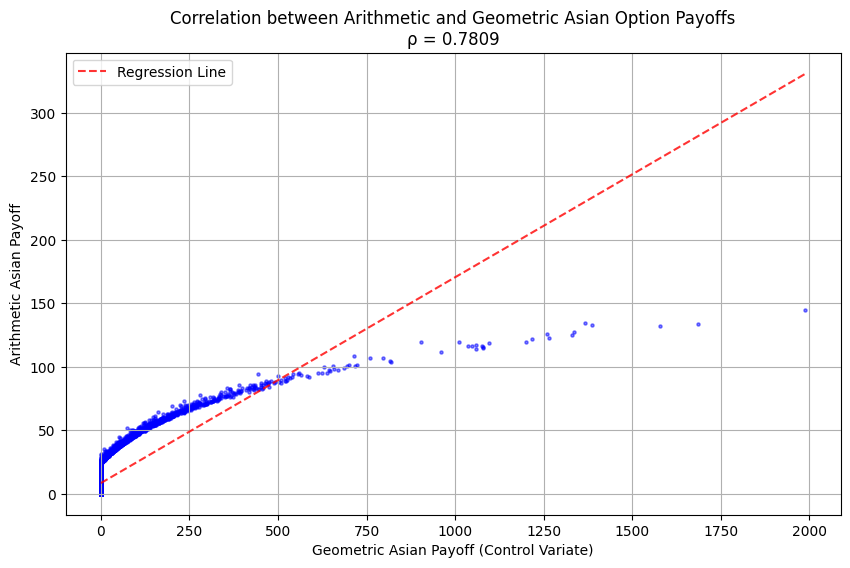

In [5]:
# Generate paths and compute payoffs
Z = sim.draw_quasi_random_numbers(sim.base_seed, N, sim.M)

# Simulate paths and compute payoffs for both arithmetic and geometric options
S_cev = sim.sim_CEV_paths(N, Z, euler=True)  # Using Euler scheme for CEV
X = np.exp(-sim.r*sim.T)*np.maximum(S_cev[:,1:].mean(1)-sim.K, 0.0)  # Arithmetic Asian payoff
Y = sim.sim_GBM_paths(N, Z)  # Geometric Asian payoff (control variate)

# Compute correlation
correlation = np.corrcoef(X, Y)[0,1]
print(f"\nCorrelation Analysis:")
print(f"Correlation between arithmetic and geometric payoffs: {correlation:.4f}")

# Basic statistics
print(f"\nArithmetic Payoff (X):")
print(f"Mean: {X.mean():.4f}")
print(f"Std Dev: {X.std():.4f}")
print(f"\nGeometric Payoff (Y):")
print(f"Mean: {Y.mean():.4f}")
print(f"Std Dev: {Y.std():.4f}")

# Create scatter plot
plt.figure(figsize=(10,6))
plt.scatter(Y, X, alpha=0.5, s=5, color='blue')
plt.xlabel('Geometric Asian Payoff (Control Variate)')
plt.ylabel('Arithmetic Asian Payoff')
plt.title(f'Correlation between Arithmetic and Geometric Asian Option Payoffs\nρ = {correlation:.4f}')
plt.grid(True)

# Add the regression line
z = np.polyfit(Y, X, 1)
p = np.poly1d(z)
y_range = np.linspace(Y.min(), Y.max(), 100)
plt.plot(y_range, p(y_range), 'r--', alpha=0.8, label='Regression Line')
plt.legend()

plt.show()

## Convergence Analysis

Plot of convergence for each method as we increase the number of paths:

Estimated fixed beta from pilot RQMC: 0.599128
Estimated fixed beta from pilot RQMC: 0.599128
Estimated fixed beta from pilot RQMC: 0.599128
Estimated fixed beta from pilot RQMC: 0.599128
Estimated fixed beta from pilot RQMC: 0.599128
Estimated fixed beta from pilot RQMC: 0.599128
Estimated fixed beta from pilot RQMC: 0.599128
Estimated fixed beta from pilot RQMC: 0.599128


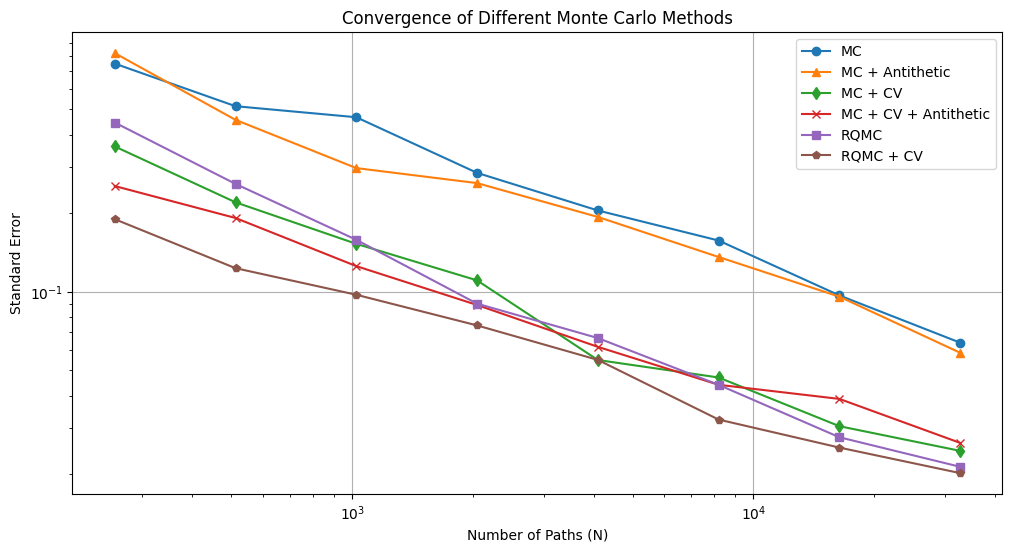

In [24]:
# Powers of 2 for QMC compatibility
N_values = [2**i for i in range(8, 16)]

# Get convergence data for each method
mc_prices, mc_errors = sim.plot_convergence(N_values, method='mc', batches=batches)
qmc_prices, qmc_errors = sim.plot_convergence(N_values, method='qmc', batches=batches)
mc_anti_prices, anti_errors = sim.plot_convergence(N_values, method='antithetic', batches=batches)
mc_cv_prices, cv_errors = sim.plot_convergence(N_values, method='mc + cv', batches=batches)
mc_cv_anti_prices, cv_anti_errors = sim.plot_convergence(N_values, method='mc + cv + antithetic', batches=batches)
qmc_cv_prices, qmc_cv_errors = sim.plot_convergence(N_values, method='qmc + cv', batches=batches)

# Plot results
plt.figure(figsize=(12, 6))
plt.loglog(N_values, mc_errors, 'o-', label='MC')
plt.loglog(N_values, anti_errors, '^-', label='MC + Antithetic')
plt.loglog(N_values, cv_errors, 'd-', label='MC + CV')
plt.loglog(N_values, cv_anti_errors, 'x-', label='MC + CV + Antithetic')
plt.loglog(N_values, qmc_errors, 's-', label='RQMC')
plt.loglog(N_values, qmc_cv_errors, 'p-', label='RQMC + CV')
plt.grid(True)
plt.xlabel('Number of Paths (N)')
plt.ylabel('Standard Error')
plt.title('Convergence of Different Monte Carlo Methods')
plt.legend()
plt.show()

# Sensitivity Analysis
## Setup for sensitivty Analysis

In [28]:
#Compare MC vs RQMC Greeks
results = sim.compare_greeks_methods(N, batches=batches, euler=False)

S0=100
#Unpack MC results
(mc_delta_mean, mc_delta_se, mc_delta_ci, _, _ ), (mc_vega_mean, mc_vega_se, mc_vega_ci, _, _) = (results['Standard MC']['Delta'], results['Standard MC']['Vega']
)
print(f"MC   Delta mean: {mc_delta_mean:.6f}, 95% CI: [{mc_delta_ci[0]:.6f}, {mc_delta_ci[1]:.6f}], se: {mc_delta_se:.6f}")
print(f"MC   Vega  mean: {mc_vega_mean:.6f}, 95% CI: [{mc_vega_ci[0]:.6f}, {mc_vega_ci[1]:.6f}], se: {mc_vega_se:.6f}")

#Unpack RQMC results
(delta_mean, delta_se, delta_ci, _, _), (vega_mean, vega_se, vega_ci, _, _) = (
    results['RQMC']['Delta'], results['RQMC']['Vega']
)

print(f"RQMC Delta mean: {delta_mean:.6f}, 95% CI: [{delta_ci[0]:.6f}, {delta_ci[1]:.6f}], se: {delta_se:.6f}")
print(f"RQMC Vega  mean: {vega_mean:.6f}, 95% CI: [{vega_ci[0]:.6f}, {vega_ci[1]:.6f}], se: {vega_se:.6f}")


MC   Delta mean: 0.603181, 95% CI: [0.599321, 0.607042], se: 0.001893
MC   Vega  mean: 12.702724, 95% CI: [12.439434, 12.966013], se: 0.129094
RQMC Delta mean: 0.602440, 95% CI: [0.601490, 0.603389], se: 0.000466
RQMC Vega  mean: 12.714867, 95% CI: [12.600092, 12.829641], se: 0.056275


## Delta

In [36]:
# Delta
S0list = [80, 90, 100, 110, 120]
for Snull in S0list:
    sim.S0 = Snull
    price, se, ci, varbetween, _  = sim.mc_greeks_with_batches(N=2**15, batches=8, euler=False)[0]
    print(f"MC:  S0={Snull}, Price={price:.6f}, 95% CI=[{ci[0]:.6f}, {ci[1]:.6f}], SE={se:.6f}")
for Snull in S0list:
    sim.S0 = Snull
    price, se, ci, varbetween, _ = sim.rqmc_greeks_with_scrambles(N=2**15, scrambles=8, euler=False)[0]
    print(f"RQMC: S0={Snull}, Price={price:.6f}, 95% CI=[{ci[0]:.6f}, {ci[1]:.6f}], SE={se:.6f}")


MC:  S0=80, Price=0.154504, 95% CI=[0.152566, 0.156441], SE=0.000819
MC:  S0=90, Price=0.340584, 95% CI=[0.337121, 0.344048], SE=0.001465
MC:  S0=100, Price=0.558096, 95% CI=[0.555163, 0.561028], SE=0.001240
MC:  S0=110, Price=0.744151, 95% CI=[0.741559, 0.746744], SE=0.001096
MC:  S0=120, Price=0.866807, 95% CI=[0.865031, 0.868584], SE=0.000751
RQMC: S0=80, Price=0.153784, 95% CI=[0.153246, 0.154321], SE=0.000227
RQMC: S0=90, Price=0.340106, 95% CI=[0.338406, 0.341807], SE=0.000719
RQMC: S0=100, Price=0.558519, 95% CI=[0.557089, 0.559949], SE=0.000605
RQMC: S0=110, Price=0.744848, 95% CI=[0.743377, 0.746318], SE=0.000622
RQMC: S0=120, Price=0.867867, 95% CI=[0.867068, 0.868667], SE=0.000338


## Vega

In [37]:
#Vega 
vegalist = [0.5, 1.0, 1.5, 2.0]
for sigmanull in vegalist:
    sim.sigma = sigmanull
    price, se, ci, varbetween, _ = sim.mc_greeks_with_batches(N=2**15, batches=8, euler=False)[1]
    print(f"MC:  sigma={sigmanull}, Price={price:.6f}, 95% CI=[{ci[0]:.6f}, {ci[1]:.6f}], SE={se:.6f}")
for sigmanull in vegalist:
    sim.sigma = sigmanull
    price, se, ci, varbetween, _ = sim.rqmc_greeks_with_scrambles(N=2**15, scrambles=8, euler=False)[1]
    print(f"RQMC: sigma={sigmanull}, Price={price:.6f}, 95% CI=[{ci[0]:.6f}, {ci[1]:.6f}], SE={se:.6f}")

MC:  sigma=0.5, Price=7.928491, 95% CI=[7.735905, 8.121078], SE=0.081445
MC:  sigma=1.0, Price=12.576411, 95% CI=[12.397640, 12.755181], SE=0.075602
MC:  sigma=1.5, Price=13.333325, 95% CI=[13.132313, 13.534337], SE=0.085008
MC:  sigma=2.0, Price=13.111016, 95% CI=[12.896082, 13.325951], SE=0.090896
RQMC: sigma=0.5, Price=7.876541, 95% CI=[7.832622, 7.920460], SE=0.018573
RQMC: sigma=1.0, Price=12.535356, 95% CI=[12.461681, 12.609031], SE=0.031157
RQMC: sigma=1.5, Price=13.271770, 95% CI=[13.174729, 13.368811], SE=0.041039
RQMC: sigma=2.0, Price=13.072120, 95% CI=[12.941877, 13.202363], SE=0.055080


## Plotting Convergence
### Delta Convergence

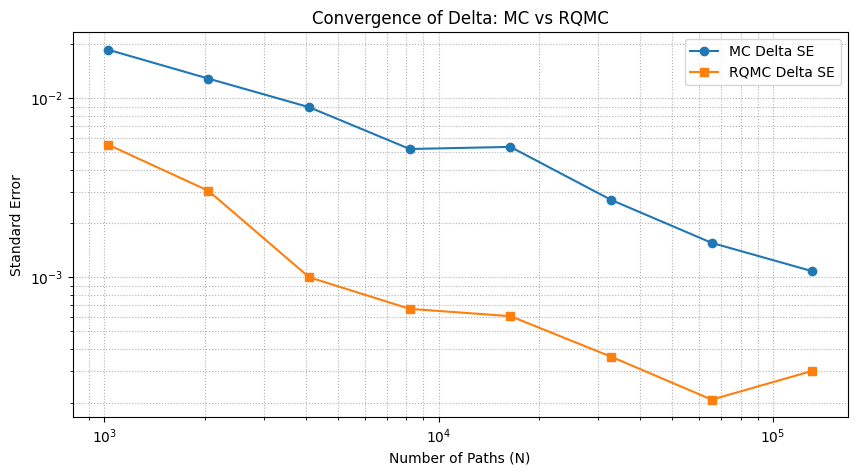

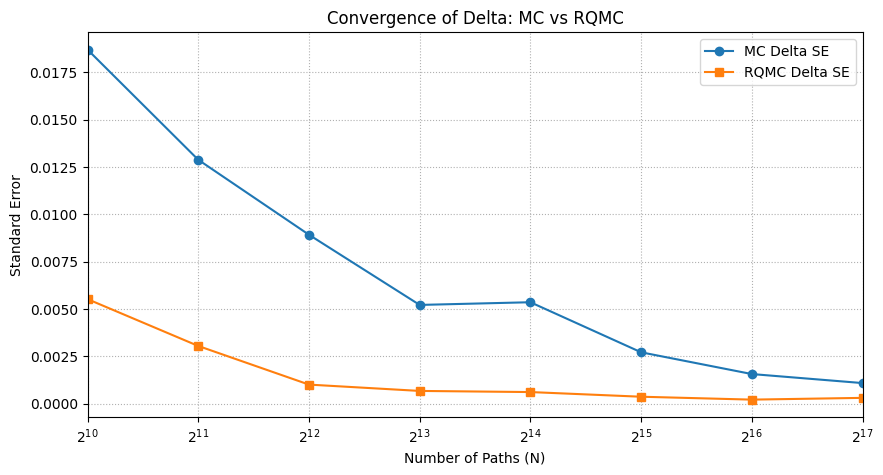

In [42]:
# Convergence of Delta (SE vs N) for MC vs RQMC
N_values = [2**i for i in range(10, 18)]  # 1024 to 131072
batches_plot = min(batches, 4)
scrambles_plot = min(batches, 4)

se_mc_delta = []
se_rqmc_delta = []

for N in N_values:
    # MC batches
    (d_mean_mc, d_se_mc, _, _, _), _ = sim.mc_greeks_with_batches(N, batches=batches_plot, euler=False)
    se_mc_delta.append(d_se_mc)

    # RQMC scrambles
    (d_mean_q, d_se_q, _, _, _), _ = sim.rqmc_greeks_with_scrambles(N, scrambles=scrambles_plot, euler=False)
    se_rqmc_delta.append(d_se_q)

plt.figure(figsize=(10, 5))
plt.loglog(N_values, se_mc_delta, 'o-', label='MC Delta SE')
plt.loglog(N_values, se_rqmc_delta, 's-', label='RQMC Delta SE')
plt.xlabel('Number of Paths (N)')
plt.ylabel('Standard Error')
plt.title('Convergence of Delta: MC vs RQMC')
plt.grid(True, which='both', ls=':')
plt.legend()
plt.show()
plt.figure(figsize=(10, 5))
plt.plot(np.log2(N_values), se_mc_delta, 'o-', label='MC Delta SE')
plt.plot(np.log2(N_values), se_rqmc_delta, 's-', label='RQMC Delta SE')
plt.xticks(np.log2(N_values), labels=[f'$2^{int(np.log2(n))}$' for n in N_values])
plt.xlim([np.log2(N_values[0]), np.log2(N_values[-1])])
plt.xticks(np.log2(N_values), labels=[f'$2^{{{int(np.log2(n))}}}$' for n in N_values])
plt.xlabel('Number of Paths (N)')
plt.ylabel('Standard Error')
plt.title('Convergence of Delta: MC vs RQMC')
plt.grid(True, which='both', ls=':')
plt.legend()
plt.show()

### Vega Convergence

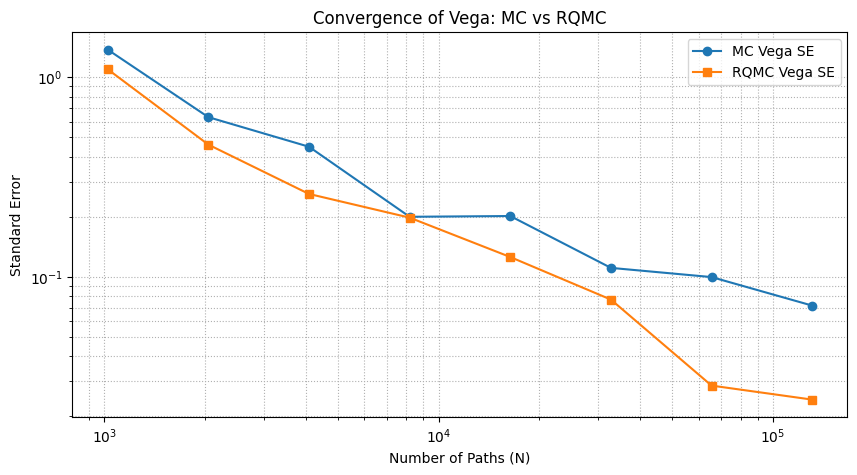

In [41]:
# Convergence of Vega (SE vs N) for MC vs RQMC
se_mc_vega = []
se_rqmc_vega = []

for N in N_values:
    # MC batches
    _, (v_mean_mc, v_se_mc, _, _, _) = sim.mc_greeks_with_batches(N, batches=batches_plot, euler=False)
    se_mc_vega.append(v_se_mc)

    # RQMC scrambles
    _, (v_mean_q, v_se_q, _, _, _) = sim.rqmc_greeks_with_scrambles(N, scrambles=scrambles_plot, euler=False)
    se_rqmc_vega.append(v_se_q)

plt.figure(figsize=(10, 5))
plt.loglog(N_values, se_mc_vega, 'o-', label='MC Vega SE')
plt.loglog(N_values, se_rqmc_vega, 's-', label='RQMC Vega SE')
plt.xlabel('Number of Paths (N)')
plt.ylabel('Standard Error')
plt.title('Convergence of Vega: MC vs RQMC')
plt.grid(True, which='both', ls=':')
plt.legend()
plt.show()